<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
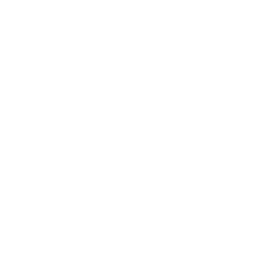
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Eficácia da Divulgação por Representantes de Vendas com Seleção de Defasagens</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Análise Farmacêutica / Comercial &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Avalie o impacto das visitas de divulgação médica e da distribuição de amostras sobre o volume mensal de prescrições de um medicamento de especialidade usando PROC AUTOREG. Considere padrões de prescrição autocorrelacionados com NLAG=3 e aplique a opção BACKSTEP para descartar automaticamente as ordens de defasagem insignificantes. Quantifique o retorno marginal de cada visita de divulgação adicional para embasar decisões de alocação da força de campo e o alinhamento de territórios.

A série mensal sintética é limitada a 100 observações no modo de execução atual, o que é suficiente para recuperar os efeitos de divulgação, amostragem, formulário e concorrência com alta precisão.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.DETAILING | Prescrições mensais com métricas de divulgação e amostras | 100 |

---

In [1]:
/* --------------------------------------------------------
   Gerar dados sintéticos mensais de divulgação e de Rx
   para um produto farmacêutico de especialidade
   -------------------------------------------------------- */
DADOS work.detailing;
    CHAMAR streaminit(42);
    RETER prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    FAZER month_seq = 1 ATÉ 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* a atribuição de território alterna entre 12 representantes */
        rep_id = cat('REP-', PUT(mod(month_seq - 1, 12) + 1, z3.));
        /* visitas de divulgação por mês */
        detail_visits = int(rand('normal', 8, 3));
        SE detail_visits < 0 ENTÃO detail_visits = 0;
        SE detail_visits > 20 ENTÃO detail_visits = 20;
        /* unidades de amostra deixadas com os médicos */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* status no formulário de managed care (binário) */
        formulary_status = (rand('uniform') > 0.2);
        /* pressão da participação do concorrente */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* índice sazonal */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* processo de erro AR(3) */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* modelo de prescrições */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        SE new_rx < 0 ENTÃO new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        SAÍDA;
    FIM;
    REMOVER prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    FORMATO obs_month monyy7.;
    RÓTULO new_rx="Novas Prescrições (NRx)"
           total_rx="Prescrições Totais"
           detail_visits="Visitas de Divulgação"
           samples_left="Amostras Deixadas"
           competitor_share="Participação do Concorrente"
           formulary_status="Status no Formulário";
EXECUTAR;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Estatísticas descritivas de base para Rx e divulgação
   -------------------------------------------------------- */
PROCEDIMENTO MÉDIAS DADOS=work.detailing n mean std MIN MAX;
    VARIÁVEL new_rx total_rx detail_visits samples_left competitor_share;
    RÓTULO new_rx="Novas Prescrições (NRx)"
           total_rx="Prescrições Totais"
           detail_visits="Visitas de Divulgação"
           samples_left="Amostras Deixadas"
           competitor_share="Participação do Concorrente";
EXECUTAR;

                                                  The MEANS Procedure

 Variable          Label                                 N            Mean        Std Dev        Minimum         Maximum
 -----------------------------------------------------------------------------------------------------------------------
 new_rx            Novas Prescrições (NRx)             100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Prescrições Totais                  100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Visitas de Divulgação               100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Amostras Deixadas                   100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Participação do Concorrente         100       0.2653000      0.1187090      0.0300000       0.5600000
 ---------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


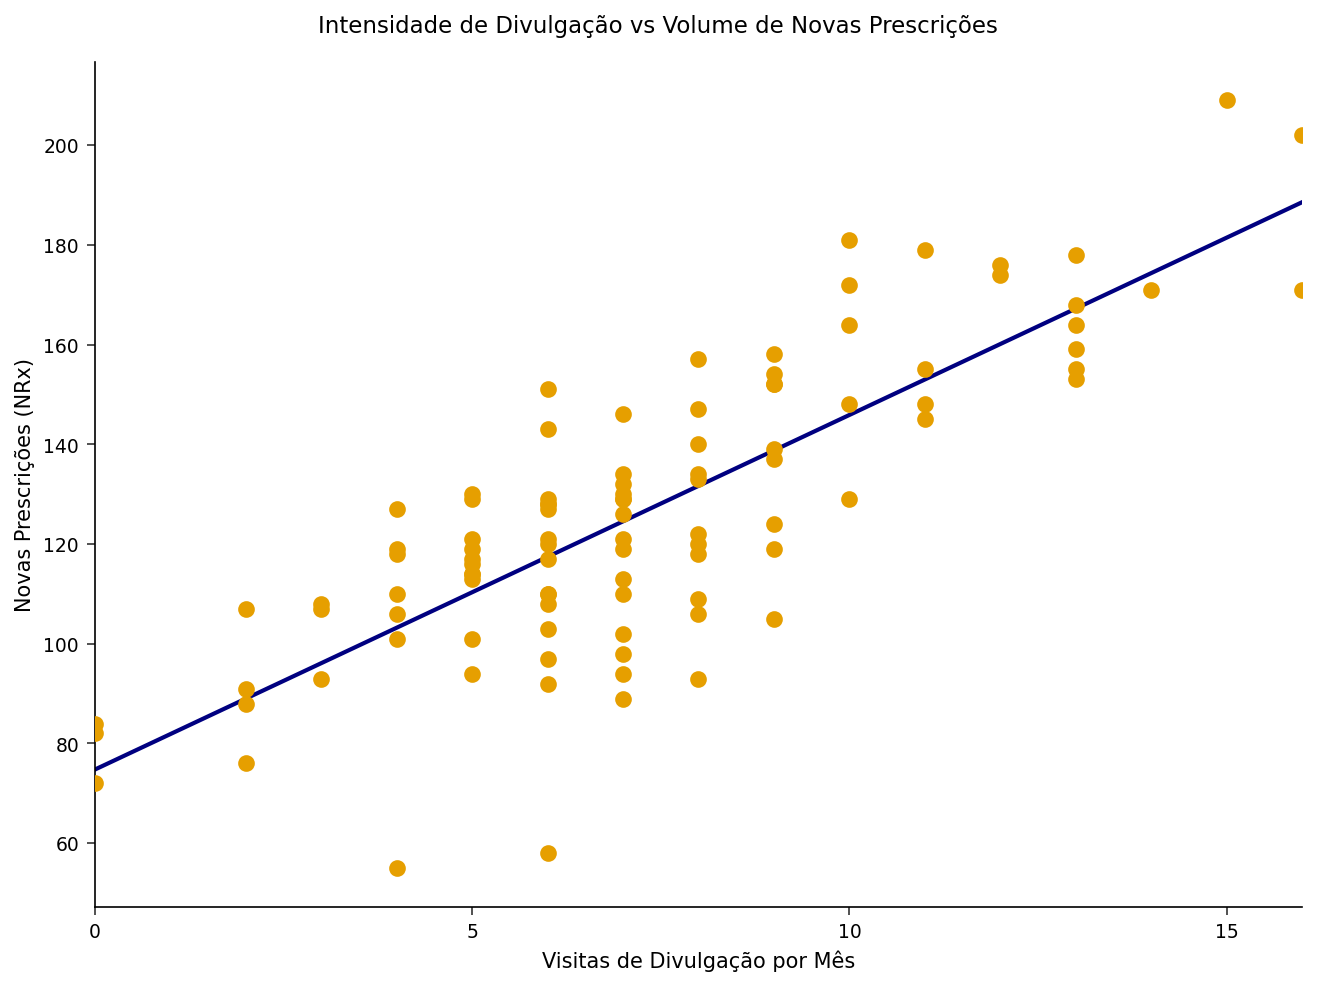

In [3]:
/* --------------------------------------------------------
   Dispersão de visitas de divulgação vs novas prescrições
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS RÓTULO="Visitas de Divulgação por Mês";
    YAXIS RÓTULO="Novas Prescrições (NRx)";
    TÍTULO "Intensidade de Divulgação vs Volume de Novas Prescrições";
EXECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Ajustar modelo autorregressivo com seleção de defasagens
   BACKSTEP. NLAG=3 testa até três defasagens; BACKSTEP
   remove automaticamente as defasagens não significativas
   -------------------------------------------------------- */
PROCEDIMENTO autoreg DADOS=work.detailing;
    MODELO new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    SAÍDA out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
EXECUTAR;


                     The AUTOREG Procedure

                     Dependent Variable   Novas Prescrições (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

            2     -0.199501   0.097990      -2.04



                        Fit Statistics


          SSE     


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Capturar as estimativas dos parâmetros para o cálculo do ROI
   -------------------------------------------------------- */
ODS SAÍDA parameterestimates=work.detail_params;

PROCEDIMENTO autoreg DADOS=work.detailing;
    MODELO new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
EXECUTAR;

ODS SAÍDA CLOSE;


                     The AUTOREG Procedure

                     Dependent Variable   Novas Prescrições (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

            2     -0.199501   0.097990      -2.04



                        Fit Statistics


          SSE     


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Calcular o ROI marginal por visita de divulgação.
   O conjunto ODS ParameterEstimates armazena a coluna
   Variable em maiúsculas, então filtre por 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROCEDIMENTO IMPRIMIR DADOS=work.detail_params;
    ONDE variable = 'DETAIL_VISITS';
    TÍTULO "Efeito Marginal das Visitas de Divulgação sobre NRx";
EXECUTAR;

                                  Efeito Marginal das Visitas de Divulgação sobre NRx                                   

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Interpretação

O PROC AUTOREG ajustou a série de prescrições em 100 observações mensais. Cada visita de divulgação adicional está associada a **+2.72 novas prescrições por mês** (estimativa 2.7158, t = 7.66, p < 0.0001), e cada unidade de amostras deixada com os médicos adiciona **+1.00 NRx** (estimativa 0.9997, t = 14.73), indicando que a amostragem reforça, mas não substitui, a promoção presencial. O acesso ao formulário contribui com **+24.78 NRx por mês** (t = 13.83), destacando o acesso via gestão de saúde (managed care) como pré-condição para a eficácia da divulgação, enquanto a participação do concorrente exerce um forte efeito negativo de **-42.26 NRx por unidade de participação** (t = -6.96), sinalizando territórios sob pressão competitiva onde a divulgação isolada pode ser insuficiente. O intercepto é 69.56.

Com NLAG=3 e BACKSTEP, o modelo reteve **duas defasagens autorregressivas**: defasagem 1 (coeficiente -0.3700, t = -3.78) e defasagem 2 (coeficiente -0.1995, t = -2.04); a defasagem 3 foi descartada como insignificante. A estatística de Durbin-Watson pós-correção é **1.01**, que ainda permanece bem abaixo de 2 e sinaliza autocorrelação positiva residual, de modo que a estrutura AR(2) captura parte, mas não toda, a dependência serial desta série. Estatísticas de ajuste: SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, log-verossimilhança = -342.67.

O planejamento da força de campo deve priorizar territórios com acesso favorável ao formulário e participação moderada do concorrente, onde o retorno marginal de cada visita de divulgação é mais alto.

---

In [7]:
/* --------------------------------------------------------
   Exportar valores ajustados e parâmetros para o painel
   de planejamento da força de campo
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>